In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEMOVO.csv')

In [3]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346,1,1,1
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532,1,1,1
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368,1,1,1
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126,1,1,1
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686,2,7,6
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550,2,7,6
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411,2,7,6
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469,2,7,6


In [5]:
df = data

In [6]:
df.shape

(588, 196)

In [7]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346,1,1,1
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532,1,1,1
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368,1,1,1
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126,1,1,1
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686,2,7,6
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550,2,7,6
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411,2,7,6
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469,2,7,6


In [8]:
data.iloc[:,-3] == 1 

0       True
1       True
2       True
3       True
4       True
       ...  
583    False
584    False
585    False
586    False
587    False
Name: gender, Length: 588, dtype: bool

In [9]:
X = df.iloc[:, :40].copy()
y = df.iloc[:,-2].copy()

In [10]:
X

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,1.790987,4.059853,0.108125,0.508598,-2.667064,2.082949,3.530962,0.235472,-1.204879,-1.216945
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,3.100928,2.010315,-0.354448,1.341924,-1.936820,1.653624,-1.788737,0.962684,0.210615,0.389378
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,3.721927,6.388279,-0.328084,3.365933,1.244843,-0.000156,-4.434872,-2.748577,-2.621502,-0.820437
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,-0.207802,2.282589,1.856748,1.048966,0.896426,-1.456609,-2.320465,1.332786,1.809331,3.004571
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,4.819692,0.991229,-1.646272,-1.396632,0.333545,1.546039,-0.322560,0.799678,-0.342907,1.447559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,0.606988,0.432341,-4.229321,-0.084617,-1.505595,-3.539907,-0.070133,-2.009664,-1.846356,-2.534840
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,-0.112556,-1.536714,-0.214943,-0.599891,-1.878961,-1.367203,-1.349430,-1.411110,-2.635400,-2.207351
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,-1.567242,0.155410,-1.748375,3.162317,-2.890250,-0.418715,-2.247914,-2.043139,-1.782257,-2.206766
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,-1.102713,0.062612,-0.039872,-0.219750,-0.067242,-0.755479,-0.632992,-1.247219,-2.024979,-1.585360


In [11]:
y

0      1
1      1
2      1
3      1
4      1
      ..
583    7
584    7
585    7
586    7
587    7
Name: labels, Length: 588, dtype: int64

In [12]:
X.shape, y.shape

((588, 40), (588,))

In [13]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()
y_encoded = lb.fit_transform(y)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [15]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


svm_clf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.4576271186440678
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.19      0.21        16
           1       0.39      0.53      0.45        17
           2       0.57      0.47      0.52        17
           3       0.60      0.18      0.27        17
           4       0.93      0.82      0.88        17
           5       0.44      0.24      0.31        17
           6       0.33      0.76      0.46        17

    accuracy                           0.46       118
   macro avg       0.50      0.46      0.44       118
weighted avg       0.50      0.46      0.44       118

SVM Confusion Matrix:
 [[ 3  3  1  1  0  2  6]
 [ 3  9  2  0  1  0  2]
 [ 2  2  8  0  0  0  5]
 [ 1  4  0  3  0  2  7]
 [ 1  0  2  0 14  0  0]
 [ 1  5  0  0  0  4  7]
 [ 1  0  1  1  0  1 13]]


In [16]:
import seaborn as sns

def plot_cm(y_true, y_pred, classes, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # row-wise percentage
    plt.figure(figsize=(7,6))
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=classes, yticklabels=classes)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(title)
    plt.show()

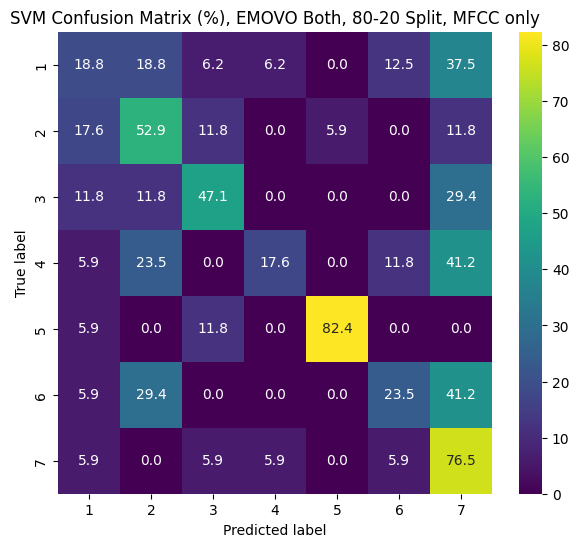

In [17]:
class_names = lb.classes_
plot_cm(y_test, y_pred_svm, class_names, title='SVM Confusion Matrix (%), EMOVO Both, 80-20 Split, MFCC only')

In [18]:
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=None, random_state=42
)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF Classification Report:\n", classification_report(y_test, y_pred_rf))
print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

RF Accuracy: 0.7627118644067796
RF Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75        16
           1       0.65      0.65      0.65        17
           2       0.81      1.00      0.89        17
           3       0.92      0.65      0.76        17
           4       0.82      0.82      0.82        17
           5       0.60      0.71      0.65        17
           6       0.87      0.76      0.81        17

    accuracy                           0.76       118
   macro avg       0.77      0.76      0.76       118
weighted avg       0.77      0.76      0.76       118

RF Confusion Matrix:
 [[12  1  1  0  0  1  1]
 [ 3 11  1  0  1  1  0]
 [ 0  0 17  0  0  0  0]
 [ 0  1  0 11  2  2  1]
 [ 0  0  1  0 14  2  0]
 [ 1  4  0  0  0 12  0]
 [ 0  0  1  1  0  2 13]]


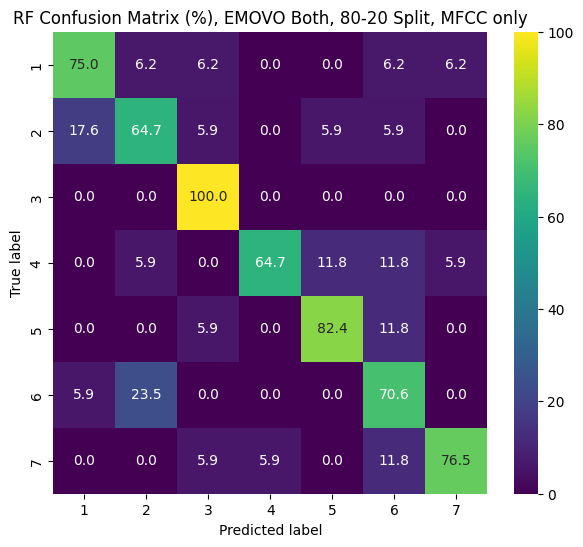

In [19]:
plot_cm(y_test, y_pred_rf, class_names, title='RF Confusion Matrix (%), EMOVO Both, 80-20 Split, MFCC only')